You are tasked to create spring boot 4 with java 25 project
using maven
the pom xml file will include the following libraries: 
Hikari,

Generate all the necessary files
generate the provided datamodel into a database postgresql 
or at least generate the commands pgsql 18 to create the database matching
the datamodel provided below
the backend should include all CRUDs with Rest api
all api calls need to be functional when tested while each request has the right logging for example wrong or unavailable id
I will personally then test all the CRUDs using postman and json
before you proceed confirm with me that you understood the datamodel
and that you successfully loaded the mermaid ERD diagram provided
in my prompt and files
The project will be generated within this directory this is the project repository


task1.ipynb contains details + the datamodel in mmd triple quote as markdown
datamodel.mmd contains the datamodel in mermaid
below is the explanation of how the datamodel is formed


span of services ranging from [15,20,25,30]

These are the possible values for services

as if time is insufficiant then it's possible to go for the Value 

of  `X_2` which is activated by `1` meaning double of the time 

if value is `0` then it means a singular session 

for example: 

if span value equals 15 

if `X_2` is 0 it's 15 

else if it's 1 then the value doubles into 30

For now The data model will contain the following tables only:

    ["S (Services)","E (Employees)","C (Clients)","ES (Employee_x_Services)","N (ES_Notification)","R (Rendez_vous)"]

## Services or S 
has id , lib , time_value 
    id:int
    lib:String
    time_value:int

## Employees or E
    id:int
    lib:String
    
    E[id] = {
                id: id,
                lib: lib,
            };

## Clients or C
    id:int
    lib:String
    number:String "phone number"

    C[i + 1] = 
            {
            id: i + 1,
            lib: "C" + Number(i + 1),
            number:Insert_phone_Number(i)
            };

## Employee_x_Services or ES 
    id: int
    id_E: int
    id_S: int,
    X_2: boolean,
    start: time "HH:mm",
    end: time "HH:mm",
    date: null "day/month/year",
    status: String "taken or free",


           ES[ES_Counter] = {
                id: ES_Counter,
                id_E: document.querySelector(".active").id,
                id_S: Number(Sid),
                X_2: 0,
                start: null,
                end: null,
                date: null,
                status: -1,
            };
end & start are time values following the standard norms of time 

### status will tell us whether the ES has been booked and reserved to a C (customer)
or not using date

when ES is booked it would be added as Rendez_vous in the R table
else free ES are waiting for a C (client) to book them

ES doesn't stock the id_C 

However R stocks the id_C because it's directly linked with C and Notification table

C is only concerned when the Rendez_vous is established

that's why R stocks the id_C and ES doesn't stock the id_C

a free ES which is not booked doesn't possess or need an id_C 

for functionality purposes this is the reason why we establish the R (Rendez_vous table)


Each ES represents a timeslot in which an Employee can be available to accept Client Rendez_vous


each created ES are all by default free ES

when a C(client) picks a free ES and books it 

ES turns into booked and directly and systematically a Rendez_vous row is created

## N or ES_Notification

    id: int
    id_R:int
    type:String "type of notification : booked or cancelled"
    value:String "inherits R.status ; value return R.status"

## R or Rendez-vous
    id:int
    id_ES:int
    id_C:int
    status:String "Active, Cancelled by Client, Cancelled by Employee"

### Calendar

Days 

from Monday to Friday 

Time 

from 08 to 17 or 09 to 16

```mermdaid

```mermaid
erDiagram
    S ||--o{ ES : "defines"
    E ||--o{ ES : "works"
    ES ||--o| R : "becomes a"
    C ||--o{ R : "books"
    R ||--o{ N : "triggers"

    S {
        int id PK "S.id"
        string lib "Service Name"
        int time_value "Base Duration [15, 20, 25, 30] mins"
    }

    E {
        int id PK "E.id"
        string lib "Employee Name"
    }

    C {
        int id PK "C.id"
        string lib "Client Name"
        string number "Phone Number"
    }

    ES {
        int id PK "Appointment ID (Timeslot)"
        int id_E FK "Employee ID"
        int id_S FK "Service ID"
        boolean X_2 "0=Single, 1=Double Duration"
        time start "HH:mm"
        time end "HH:mm"
        date date "YYYY/MM/DD"
        string status "e.g., 'taken', 'free'"
    }

    R {
        int id PK "Rendez-vous ID"
        int id_ES FK "Linked Timeslot ID"
        int id_C FK "Client ID"
        string status "Active, Cancelled by C, Cancelled by E"
    }

    N {
        int id PK "Notification ID"
        int id_R FK "Rendez-vous Reference"
        string type "booking or cancelled"
        string value "Inherits R.status"
    }

```

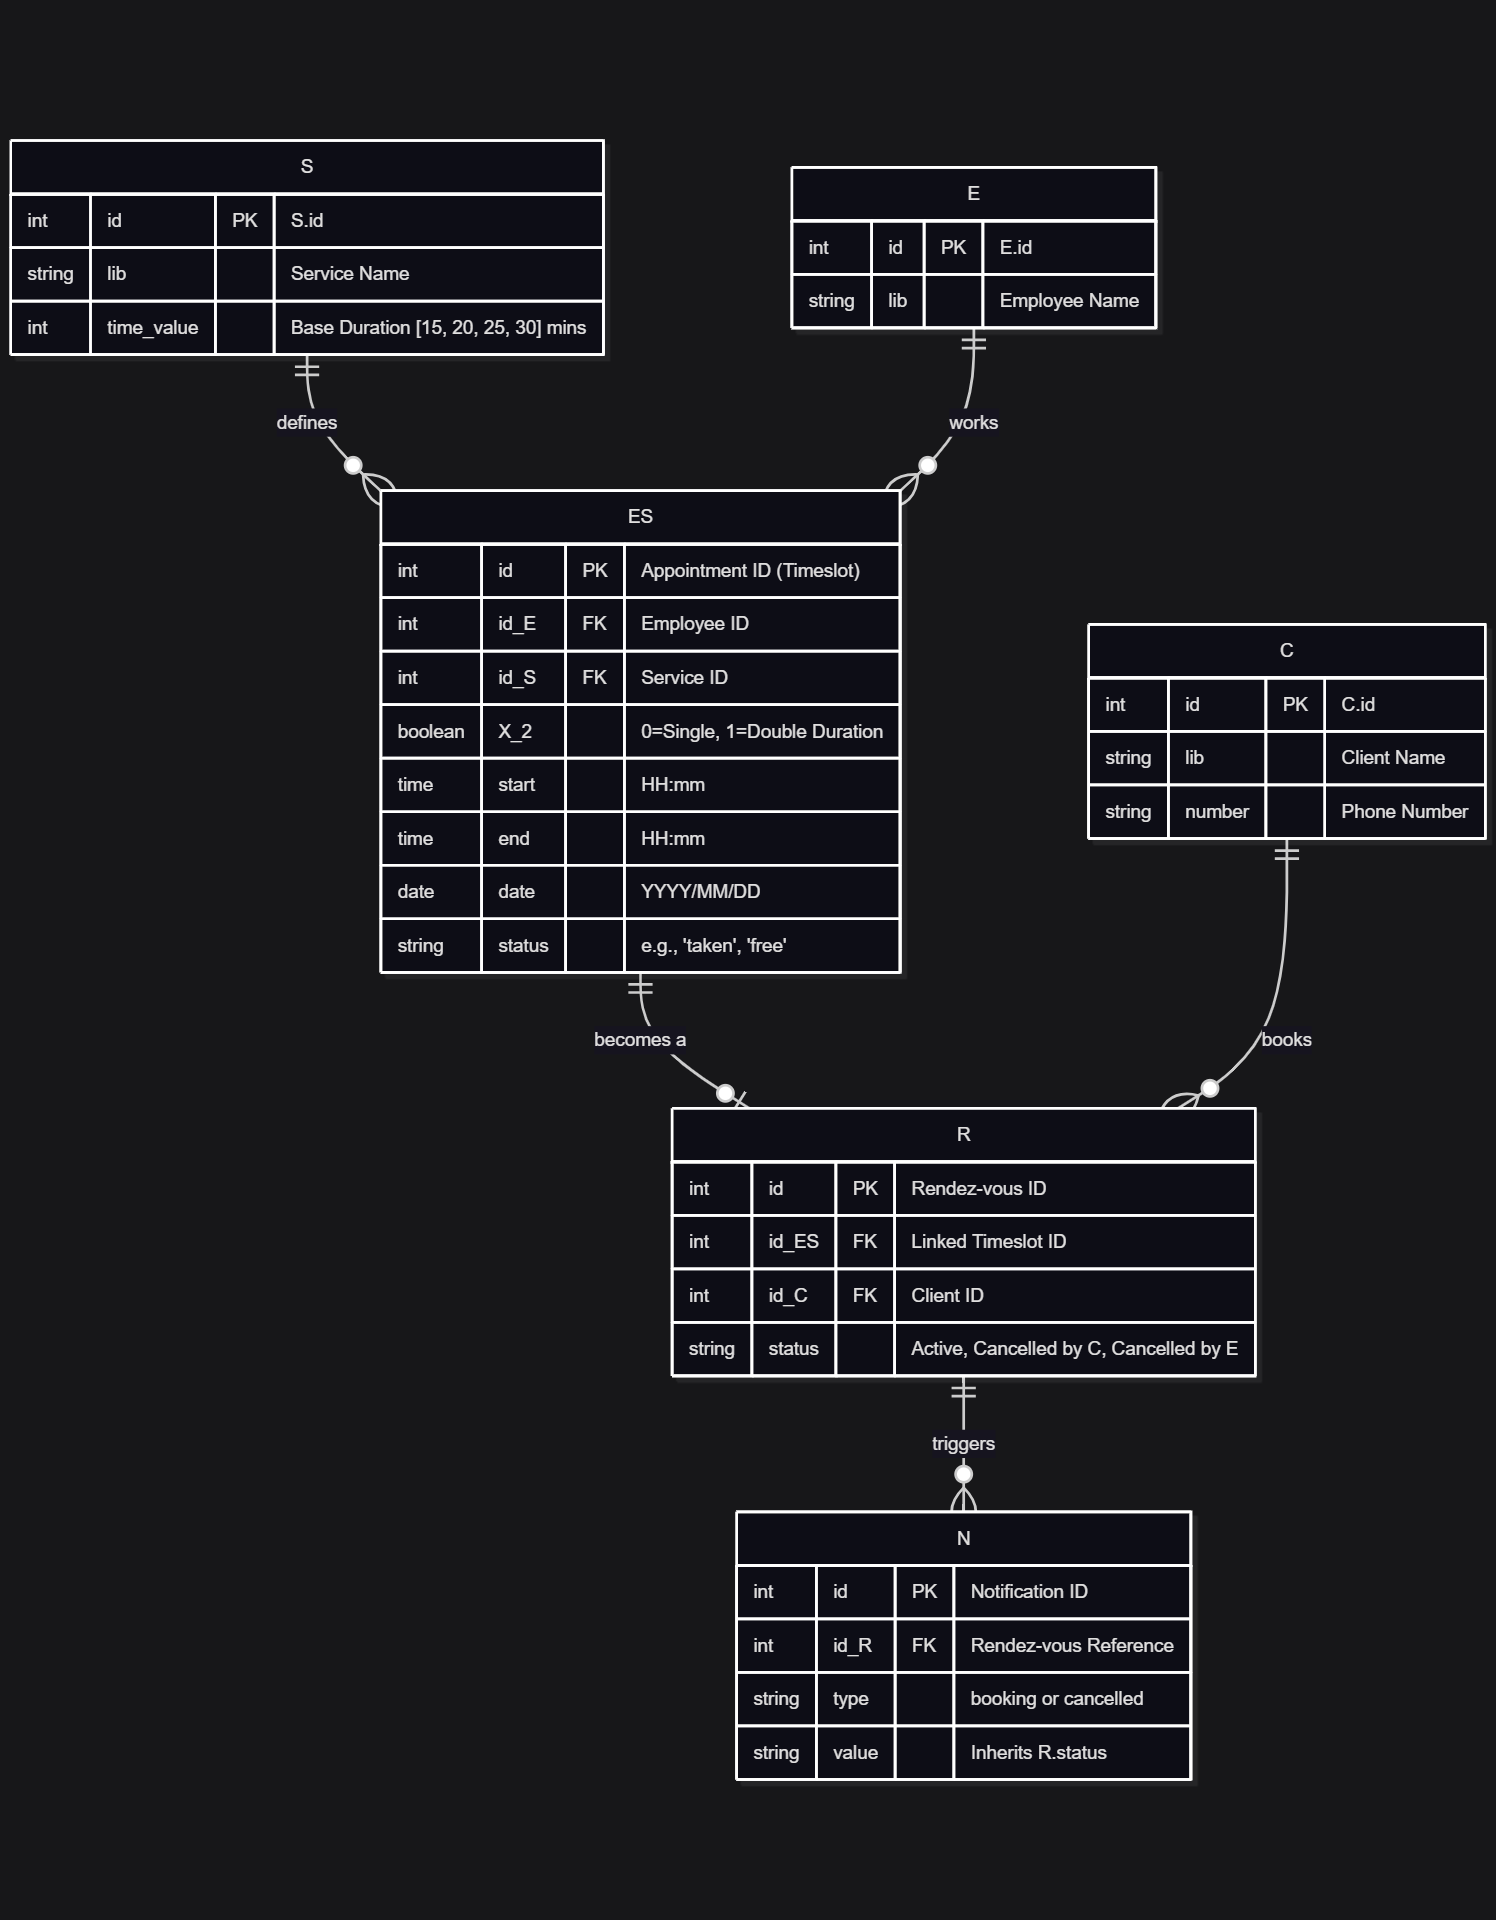